<a href="https://colab.research.google.com/github/gyeongee/TIL/blob/main/%EB%B6%84%EB%A5%98%EC%8B%A4%EC%8A%B5_%EC%BA%90%EA%B8%80%EC%8B%A0%EC%9A%A9%EC%B9%B4%EB%93%9C%EC%82%AC%EA%B8%B0%EA%B2%80%EC%B6%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kagglehub

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


In [4]:
import os
os.chdir('/kaggle/input/creditcardfraud')
print(os.getcwd())

/kaggle/input/creditcardfraud


In [5]:
ls

creditcard.csv


In [11]:
import numpy as np
import pandas as pd

card=pd.read_csv('creditcard.csv')
card

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


총 284807개의 행이 있고 31개의 칼럼이 있으며 결측치는 없다.

label 값을 제외하고 다 float 형이라 인코딩은 진행하지 않아도 될 것 같다!

Amount 피처는 신용카드 트랜잭션 금액을 의미함

In [12]:
card.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [32]:
card.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


Amount 변수의 스케일링이 필요할 듯하다

In [37]:
card.std().sort_values(ascending=False)

,0
Time,47488.145955
Amount,250.120109
V1,1.958696
V2,1.651309
V3,1.516255
V4,1.415869
V5,1.380247
V6,1.332271
V7,1.237094
V8,1.194353


위 데이터의 라벨값은 불균형한 분포를 가지고 있다.

0 : 정상적인 신용카드 트랜잭션 데이터

1: 사기 트랜잭션

사기와 같은 이상 현상은 전체 데이터에서 차지하는 비중이 매우 적음

In [13]:
# label 분포 확인
card['Class'].value_counts(normalize=True)

,proportion
Class,
0,0.998273
1,0.001727


불필요한 Time feature 제거


In [17]:
def get_preprocessed_df(df=None):
  df_copy=df.copy()
  df_copy = df_copy.drop('Time',axis=1)
  return df_copy



get_train_test_dataset() 내부에서 get_preprocessed_df() 함수 호출하며, 테스트 데이터 세트를 전체 30%인 Stratified 방식으로 추출해 학습 데이터 세트와 테스트 데이터 세트의 레이블 값 분포도를 서로 동일하게 만듭니다.

In [18]:
from sklearn.model_selection import train_test_split

def get_train_test_dataset(df=None):
  df_copy=get_preprocessed_df(df)
  X=df_copy.iloc[:,:-1]
  y=df_copy.iloc[:,-1]
  X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,stratify=y,random_state=0)
  return X_train,X_test,y_train,y_test

X_train,X_test,y_train,y_test=get_train_test_dataset(card)

생성한 학습 데이터 세트와 테스트 데이터 세트의 레이블 값 비율을 백분율로 환산해서 서로 비슷하게 분할됐는지 확인해 보겠습니다.

In [21]:
print(f'학습 데이터 레이블 값 비율:{y_train.value_counts(normalize=True)}')
print(f'테스트 데이터 레이블 값 비율:{y_test.value_counts(normalize=True)}')

학습 데이터 레이블 값 비율:Class
0    0.998275
1    0.001725
Name: proportion, dtype: float64
테스트 데이터 레이블 값 비율:Class
0    0.998268
1    0.001732
Name: proportion, dtype: float64


로지스틱 회귀와 LightGBM 기반의 모델로 모델링을 진행해보겠습니다.

In [27]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix,f1_score,roc_auc_score

def get_clf_eval(y_test,pred,pred_proba):
  acc=accuracy_score(y_test,pred)
  precision=precision_score(y_test,pred)
  recall=recall_score(y_test,pred)
  roc_auc=roc_auc_score(y_test,pred_proba)
  f1=f1_score(y_test,pred)
  print(f'오차행렬\n{confusion_matrix(y_test,pred)}')
  print(f'정확도:{acc:.4f}, 정밀도:{precision:.4f}, 재현율:{recall:.4f} F1:{f1:.4f},roc_auc:{roc_auc:.4f}')

최대 1000번 반복해서 최적의 가중치 계수를 찾겠다.

```max_iter```은 로지스틱 회귀가 학습될 때 사용하는 최적화 알고리즘의 반복 횟수 상한값입니다.

In [28]:
# 로지스틱 회귀
from sklearn.linear_model import LogisticRegression

lr= LogisticRegression(max_iter=1000)
lr.fit(X_train,y_train)
lr_pred = lr.predict(X_test)
lr_pred_proba=lr.predict_proba(X_test)[:,1]

get_clf_eval(y_test,lr_pred,lr_pred_proba)
# 확률값을 threshold로 변환 후 평가
# 0.5보다 크면 1, 아니면 0
# pred_proba_05=(lr_pred_proba >= 0.5).astype(int)


오차행렬
[[85281    14]
 [   57    91]]
정확도:0.9992, 정밀도:0.8667, 재현율:0.6149 F1:0.7194,roc_auc:0.9741


로지스틱 회귀의 재현율은 0.6419 입니다.

In [30]:
# 인자로 사이킷런의 Estimator 객체와 학습/테스트 데이터 세트를 입력받아서 학습/예측/평가 수행
def get_model_train_eval(model,ftr_train=None,ftr_test=None,tgt_train=None,tgt_test=None):
  model.fit(ftr_train,tgt_train)
  pred=model.predict(ftr_test)
  pred_proba=model.predict_proba(ftr_test)[:,1]
  get_clf_eval(tgt_test,pred,pred_proba)

레이블 값 분포도가 불균형하므로 LGBMClassifier 객체 생성 시 ```boost_from_average=False```로 파라미터를 설정해야합니다.

In [31]:
# LightGBM 모델링
from lightgbm import LGBMClassifier

lgb=LGBMClassifier(n_estimators=100, num_leaves=64,n_jobs=-1,boost_from_average=False)
get_model_train_eval(lgb,X_train,X_test,y_train,y_test)

[LightGBM] [Info] Number of positive: 344, number of negative: 199020
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.110875 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 199364, number of used features: 29
오차행렬
[[85289     6]
 [   38   110]]
정확도:0.9995, 정밀도:0.9483, 재현율:0.7432 F1:0.8333,roc_auc:0.9717


lightGBM의 재현율은 0.7432 입니다.


로지스틱 회귀로 모델링한 결과보다 LgihtGBM 모델링 결과가 더 높은 수치를 나타냈습니다.

데이터 분포도 변환 후 모델 학습/예측/평가

range()는 int형을 인자로 받기 때문에 반올림을 진행하자!(최소값의 소수점 자리는 내리고, 최대값의 소수점자리는 올림)

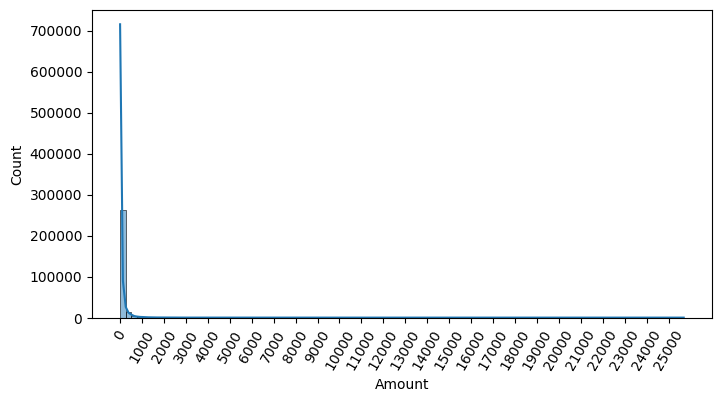

In [46]:
# Amount피처의 분포도 확인
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
# X축 눈금 설정
# rotation=60 -> 글자 기울여서 표시, 값이 많아 겹치는 것을 방지
plt.xticks(range(int(np.floor(card['Amount'].min())),int(np.ceil(card['Amount'].max())),1000),rotation=60)
# 막대를 100개 구간으로 나눔
# kde=True -> 부드러운 분포 곡선을 함께 그림
sns.histplot(card['Amount'],bins=100,kde=True)
plt.show()

plt.xticks()와 bins는 서로 다른 역할을 한다. plt.xticks()는 x축에 어떤 숫자를 얼마 간격으로 표시할지를 정하는 기능이다. 예를 들어 range(0, 30000, 1000)으로 설정하면 x축에 0, 1000, 2000처럼 1000 단위로 눈금이 표시된다.

반면 bins는 히스토그램의 막대를 몇 개의 구간으로 나눌지를 결정한다. 예를 들어 bins=100이면 전체 범위를 100개의 구간으로 나누어 각 구간의 데이터 개수를 막대로 표현한다. 만약 최소값이 0이고 최대값이 30000이라면 막대 하나의 폭은 300이 된다.

꼬리가 긴 형태의 분포 곡선을 가지고 있다.


In [49]:
from sklearn.preprocessing import StandardScaler
# 사이킷런의 StandardScaler를 이용해 정규 분포 형태로 Amount 피처값 변환하는 로직으로 수정

def get_preprocessed_df(df=None):
  df_copy=df.copy()
  scaler=StandardScaler()
  amount_n = scaler.fit_transform(df_copy['Amount'].values.reshape(-1,1))

  # 변환된 Amount를 Amount_Scaled로 피처명 변환 후 DataFrame 맨 앞 칼럼으로 입력
  df_copy.insert(0,'Amount_Scaled',amount_n)
  # 기존 Amount,Time 칼럼 삭제
  df_copy=df_copy.drop(['Amount','Time'],axis=1)
  return df_copy

In [50]:
X_train,X_test,y_train,y_test=get_train_test_dataset(card)

lr_clf=LogisticRegression(max_iter=1000)
get_model_train_eval(lr_clf,X_train,X_test,y_train,y_test)
lgbm_clf = LGBMClassifier(n_estimators=100,num_leaves=64,n_jobs=-1,boost_from_average=False)
get_model_train_eval(lgbm_clf,X_train,X_test,y_train,y_test)

오차행렬
[[85281    14]
 [   55    93]]
정확도:0.9992, 정밀도:0.8692, 재현율:0.6284 F1:0.7294,roc_auc:0.9706
[LightGBM] [Info] Number of positive: 344, number of negative: 199020
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.210919 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 199364, number of used features: 29
오차행렬
[[85289     6]
 [   39   109]]
정확도:0.9995, 정밀도:0.9478, 재현율:0.7365 F1:0.8289,roc_auc:0.9744


정규 분포 형태로 Amount 피처값을 변환한 후 테스트 데이터 세트에 적용한 로지스틱 회귀의 경우는 정밀도와 재현율이 오히려 조금 저하되었고, LightGBM의 경우는 약간 정밀도와 재현율이 저하되었지만 큰 성능상의 변경은 없습니다.

이번에는 StandardScaler가 아니라 로그 변환을 수행해보겠습니다.
원래 값을 log 값으로 변환해 원래 큰 값을 상대적으로 작은 값으로 변환하기 때문에 데이터 분포도의 왜곡을 상당 수준 개선해줍니다.

In [51]:
def get_preprocessed_df(df=None):
  df_copy=df.copy()
  amount_n = np.log1p(df_copy['Amount'])
  df_copy.insert(0,'Amount_Scaled',amount_n)
  df_copy=df_copy.drop(['Time','Amount'],axis=1)
  return df_copy

In [52]:
X_train,X_test,y_train,y_test=get_train_test_dataset(card)

lr_clf=LogisticRegression(max_iter=1000)
get_model_train_eval(lr_clf,X_train,X_test,y_train,y_test)
lgbm_clf = LGBMClassifier(n_estimators=100,num_leaves=64,n_jobs=-1,boost_from_average=False)
get_model_train_eval(lgbm_clf,X_train,X_test,y_train,y_test)

오차행렬
[[85282    13]
 [   59    89]]
정확도:0.9992, 정밀도:0.8725, 재현율:0.6014 F1:0.7120,roc_auc:0.9734
[LightGBM] [Info] Number of positive: 344, number of negative: 199020
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.114674 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 199364, number of used features: 29
오차행렬
[[85289     6]
 [   38   110]]
정확도:0.9995, 정밀도:0.9483, 재현율:0.7432 F1:0.8333,roc_auc:0.9812


로지스틱 회귀의 경우 원본 데이터 대비 정밀도는 향상되었지만 재현율은 저하되었습니다. LightGBM의 경우 재현율이 향상되었습니다. 레이블이 극도록 불균일한 데이터 세트에서 로지스틱 회귀는 데이터 변환 시 약간은 불안정한 결과를 보여주고 있습니다.

#### 이상치 데이터 제거 후 모델 학습/예측/평가